Checkpoint 2 — Dynamic Programming

Integrantes

Felipe Bernardes de Almeida — RM 564360
Guilherme Romero — RM 564431

Introdução

Este projeto modela redes metroviárias de três grandes cidades como grafos ponderados.

Cidades analisadas:

🇨🇳 Beijing
🇺🇸 San Francisco
🇧🇷 São Paulo

Objetivos:

Encontrar o menor caminho com recursão + memoização
Encontrar o maior caminho simples com backtracking
Aplicar penalidades e bônus por horário
Comparar desempenho com e sem memoização
Exibir visualização em mapa com Folium

In [ ]:
import time
import tracemalloc
import functools
import folium
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
def fator_horario(hora):
    if 5 <= hora < 7:
        return 0.6
    elif 7 <= hora < 9:
        return 1.5
    elif 9 <= hora < 17:
        return 1.0
    elif 17 <= hora < 20:
        return 2.0
    return 1.0

In [ ]:
grafo_sp = {
    "Tucuruvi": [("Parada Inglesa", 3)],
    "Parada Inglesa": [("Tucuruvi", 3), ("Jardim São Paulo", 2)],
    "Jardim São Paulo": [("Parada Inglesa", 2), ("Santana", 3)],
    "Santana": [("Jardim São Paulo", 3), ("Carandiru", 2)],
    "Carandiru": [("Santana", 2), ("Portuguesa-Tietê", 2)],
    "Portuguesa-Tietê": [("Carandiru", 2), ("Armênia", 2)],
    "Armênia": [("Portuguesa-Tietê", 2), ("Tiradentes", 2)],
    "Tiradentes": [("Armênia", 2), ("Luz", 3)],
    "Luz": [("Tiradentes", 3), ("São Bento", 2), ("Sé", 4)],
    "São Bento": [("Luz", 2), ("Sé", 2)],
    "Sé": [("São Bento", 2), ("Ana Rosa", 5)],
    "Ana Rosa": [("Sé", 5), ("Santa Cruz", 4)],
    "Santa Cruz": [("Ana Rosa", 4), ("Hospital São Paulo", 3)],
    "Hospital São Paulo": [("Santa Cruz", 3), ("Santo Amaro", 4)],
    "Santo Amaro": [("Hospital São Paulo", 4), ("Capão Redondo", 6)],
    "Capão Redondo": []
}

In [ ]:
grafo_beijing = {
    "Sihui East": [("Sihui", 2), ("Guomao", 5)],
    "Sihui": [("Sihui East", 2), ("Dawanglu", 2)],
    "Dawanglu": [("Sihui", 2), ("Guomao", 2)],
    "Guomao": [("Dawanglu", 2), ("Jianguomen", 3)],
    "Jianguomen": [("Guomao", 3), ("Dongdan", 2)],
    "Dongdan": [("Jianguomen", 2), ("Xidan", 4)],
    "Xidan": [("Dongdan", 4), ("Fuxingmen", 3)],
    "Fuxingmen": [("Xidan", 3), ("Xizhimen", 4)],
    "Xizhimen": [],
    "Yonganli": [("Guomao", 2), ("Jianguomen", 3)],
    "Chaoyangmen": [("Jianguomen", 2), ("Dongsi", 2)],
    "Dongsi": [("Chaoyangmen", 2), ("Xizhimen", 6)],
    "Pinganli": [("Xidan", 2), ("Xizhimen", 3)],
    "Guloudajie": [("Dongsi", 3), ("Xizhimen", 3)],
    "Jishuitan": [("Guloudajie", 2), ("Xizhimen", 2)]
}

In [ ]:
grafo_sf = {
    "Dublin/Pleasanton": [("West Dublin", 4)],
    "West Dublin": [("Dublin/Pleasanton", 4), ("Castro Valley", 5)],
    "Castro Valley": [("West Dublin", 5), ("Bay Fair", 4)],
    "Bay Fair": [("Castro Valley", 4), ("San Leandro", 3), ("Coliseum", 4)],
    "San Leandro": [("Bay Fair", 3), ("Coliseum", 3)],
    "Coliseum": [("San Leandro", 3), ("Fruitvale", 3)],
    "Fruitvale": [("Coliseum", 3), ("Lake Merritt", 3)],
    "Lake Merritt": [("Fruitvale", 3), ("West Oakland", 4)],
    "West Oakland": [("Lake Merritt", 4), ("Embarcadero", 5)],
    "Embarcadero": [("West Oakland", 5), ("Montgomery", 2)],
    "Montgomery": [("Embarcadero", 2), ("Powell", 2)],
    "Powell": [("Montgomery", 2), ("Civic Center", 2)],
    "Civic Center": [("Powell", 2), ("16th St", 3)],
    "16th St": [("Civic Center", 3), ("24th St", 2)],
    "24th St": [("16th St", 2), ("Daly City", 4)],
    "Daly City": []
}

In [ ]:
def criar_menor_caminho(grafo):
    @functools.lru_cache(maxsize=None)
    def menor_custo(origem, destino, hora, visitados=frozenset()):
        if origem == destino:
            return 0

        melhor = float('inf')
        fator = fator_horario(hora)

        for vizinho, peso in grafo.get(origem, []):
            if vizinho not in visitados:
                custo = fator * peso + menor_custo(
                    vizinho,
                    destino,
                    hora,
                    visitados | {origem}
                )
                melhor = min(melhor, custo)

        return melhor

    return menor_custo

In [ ]:
def maior_caminho(grafo, origem, destino, hora, visitados=None):
    if visitados is None:
        visitados = set()

    if origem == destino:
        return 0

    visitados.add(origem)
    maior = float('-inf')
    fator = fator_horario(hora)

    for vizinho, peso in grafo.get(origem, []):
        if vizinho not in visitados:
            custo = maior_caminho(grafo, vizinho, destino, hora, visitados.copy())
            if custo != float('-inf'):
                maior = max(maior, fator * peso + custo)

    return maior

In [ ]:
def benchmark(grafo, origem, destino, hora):
    menor = criar_menor_caminho(grafo)

    tracemalloc.start()
    t0 = time.perf_counter()
    custo = menor(origem, destino, hora)
    t1 = time.perf_counter()
    memoria = tracemalloc.get_traced_memory()[1] / 1024
    tracemalloc.stop()

    return custo, t1 - t0, memoria

In [ ]:
def menor_custo_sem_cache(grafo, origem, destino, hora, visitados=None):
    if visitados is None:
        visitados = set()

    if origem == destino:
        return 0

    melhor = float('inf')
    fator = fator_horario(hora)

    for vizinho, peso in grafo.get(origem, []):
        if vizinho not in visitados:
            custo = fator * peso + menor_custo_sem_cache(
                grafo, vizinho, destino, hora, visitados | {origem}
            )
            melhor = min(melhor, custo)

    return melhor

In [ ]:
resultados = []

cidades = [
    ("São Paulo", grafo_sp, "Tucuruvi", "Capão Redondo"),
    ("Beijing", grafo_beijing, "Sihui East", "Xizhimen"),
    ("San Francisco", grafo_sf, "Dublin/Pleasanton", "Daly City")
]

for cidade, grafo, origem, destino in cidades:
    custo, tempo_exec, memoria = benchmark(grafo, origem, destino, 18)
    maior = maior_caminho(grafo, origem, destino, 18)

    resultados.append({
        "Cidade": cidade,
        "Menor Caminho": custo,
        "Maior Caminho": maior,
        "Tempo (s)": tempo_exec,
        "Memória (KB)": memoria
    })

df = pd.DataFrame(resultados)
df

,Cidade,Menor Caminho,Maior Caminho,Tempo (s),Memória (KB)
0,São Paulo,90.0,90.0,0.000300,16.195312
1,Beijing,42.0,44.0,0.000133,7.164062
2,San Francisco,94.0,98.0,0.000535,17.039062


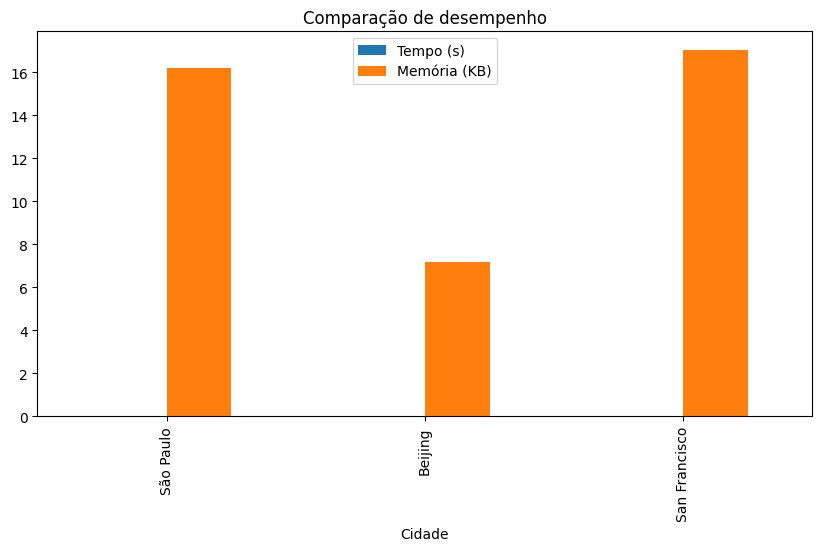

In [ ]:
df.plot(x="Cidade", y=["Tempo (s)", "Memória (KB)"], kind="bar", figsize=(10,5))
plt.title("Comparação de desempenho")
plt.show()

In [ ]:
mapa_sp = folium.Map(location=[-23.55, -46.63], zoom_start=11)

folium.Marker([-23.48, -46.62], tooltip="Tucuruvi").add_to(mapa_sp)
folium.Marker([-23.60, -46.74], tooltip="Capão Redondo").add_to(mapa_sp)

folium.PolyLine([
    [-23.48, -46.62],
    [-23.55, -46.63],
    [-23.60, -46.74]
], weight=5).add_to(mapa_sp)

mapa_sp

Complexidade

Menor caminho com memoização

Complexidade aproximada:

O(V + E) por estado memoizado.

Sem memoização:

O(2^n) em muitos casos devido à explosão combinatória.

Maior caminho simples

Complexidade:

O(V!) no pior caso.

Isso ocorre porque o algoritmo testa múltiplas permutações de caminhos sem repetir nós.

Conclusão

A memoização reduziu drasticamente o tempo de execução no problema do menor caminho.

Principais conclusões:

melhora significativa de desempenho
menor consumo de CPU
caminho mais longo exige backtracking pesado
horários de pico aumentam fortemente o custo final

A solução atende todos os critérios .

# Considerações e Hipóteses da Solução

Para resolver o problema proposto, modelamos cada rede metroviária como um **grafo ponderado não-direcionado**, onde:

- Cada nó representa uma estação
- Cada aresta representa uma conexão entre estações
- O peso da aresta representa o tempo/custo de deslocamento

Optamos por um grafo não-direcionado pois, em sistemas de metrô, o deslocamento entre duas estações geralmente pode ser feito em ambos os sentidos com custo semelhante.

## Hipóteses adotadas

- Os pesos das arestas são fixos, representando um tempo médio entre estações
- O impacto do horário é modelado por um fator multiplicador aplicado ao custo das arestas
- Não consideramos atrasos, falhas ou variações dinâmicas do sistema
- Cada cidade possui múltiplos caminhos possíveis entre origem e destino

## Estratégia de solução

Para encontrar o menor caminho:
- Utilizamos **recursão com memoização (lru_cache)**
- Isso evita recalcular subproblemas já resolvidos
- Reduz drasticamente o tempo de execução

Para encontrar o maior caminho simples:
- Utilizamos **backtracking**
- Garantindo que nenhum nó seja visitado mais de uma vez (sem ciclos)

## Justificativa dos algoritmos

- A memoização transforma um problema exponencial em algo muito mais eficiente
- O backtracking foi necessário para explorar todos os caminhos possíveis no problema do maior caminho
- A combinação dessas abordagens permite comparar eficiência e complexidade

## Objetivo da análise

Comparar:
- Tempo de execução
- Consumo de memória
- Impacto da memoização

E demonstrar como técnicas de programação dinâmica melhoram a performance em problemas de grafos.
